In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

VARIANT = 1
np.random.seed(VARIANT)

In [2]:
days = np.arange(1, 31)
is_weekend = np.isin(days % 7, [6, 0])

base_temp = 3.0
base_sales = 40.0

temperature = np.round(np.random.normal(base_temp, 1.5, size=30), 1)

weekend_boost = is_weekend * np.random.uniform(0.15, 0.25, size=30) * base_sales
sales_noise = np.random.normal(0, 3, size=30)
sales = np.round(base_sales + weekend_boost + sales_noise).astype(int)

df = pd.DataFrame({
    "день": days,
    "вихідний": is_weekend,
    "температура": temperature,
    "продажі": sales
})

print("Перші 5 рядків згенерованого DataFrame (Варіант 1 — Київ):")
print(df.head())

Перші 5 рядків згенерованого DataFrame (Варіант 1 — Київ):
   день  вихідний  температура  продажі
0     1     False          5.4       43
1     2     False          2.1       43
2     3     False          2.2       41
3     4     False          1.4       43
4     5     False          4.3       38


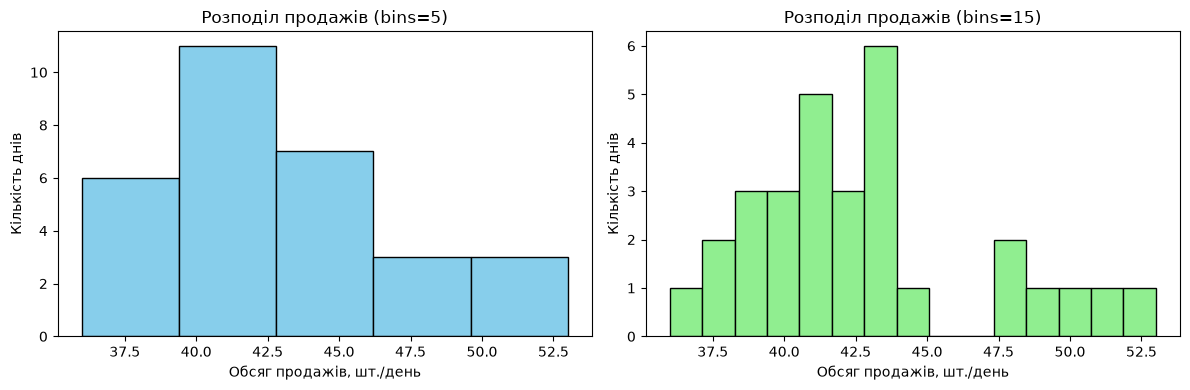

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Варіант А: bins = 5
ax1.hist(df["продажі"], bins=5, edgecolor="black", color="skyblue")
ax1.set_xlabel("Обсяг продажів, шт./день")
ax1.set_ylabel("Кількість днів")
ax1.set_title("Розподіл продажів (bins=5)")

# Варіант Б: bins = 15
ax2.hist(df["продажі"], bins=15, edgecolor="black", color="lightgreen")
ax2.set_xlabel("Обсяг продажів, шт./день")
ax2.set_ylabel("Кількість днів")
ax2.set_title("Розподіл продажів (bins=15)")

plt.tight_layout()
plt.show()

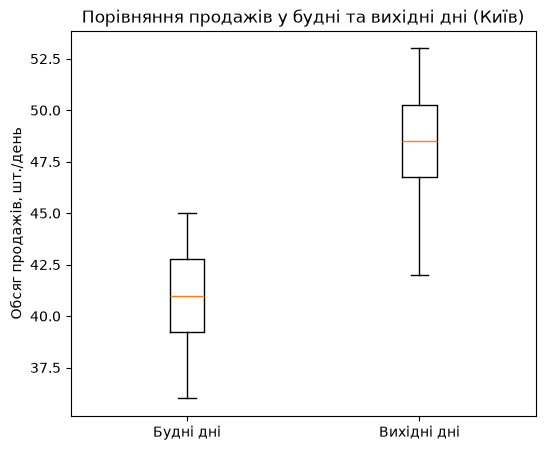

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))

weekday_sales = df.loc[~df["вихідний"], "продажі"]
weekend_sales = df.loc[df["вихідний"], "продажі"]

ax.boxplot([weekday_sales, weekend_sales], tick_labels=["Будні дні", "Вихідні дні"])
ax.set_ylabel("Обсяг продажів, шт./день")
ax.set_title("Порівняння продажів у будні та вихідні дні (Київ)")

plt.show()

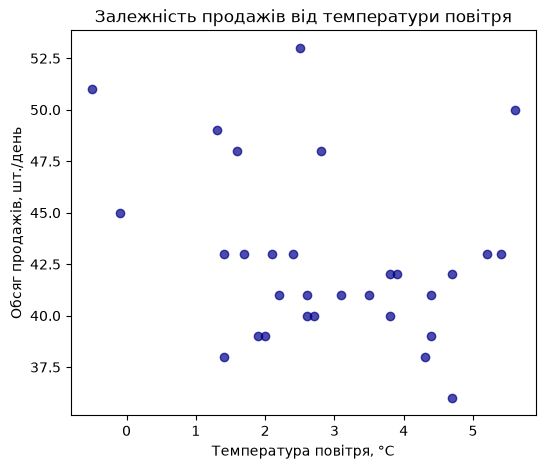

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(df["температура"], df["продажі"], color="darkblue", alpha=0.7)
ax.set_xlabel("Температура повітря, °C")
ax.set_ylabel("Обсяг продажів, шт./день")
ax.set_title("Залежність продажів від температури повітря")

plt.show()

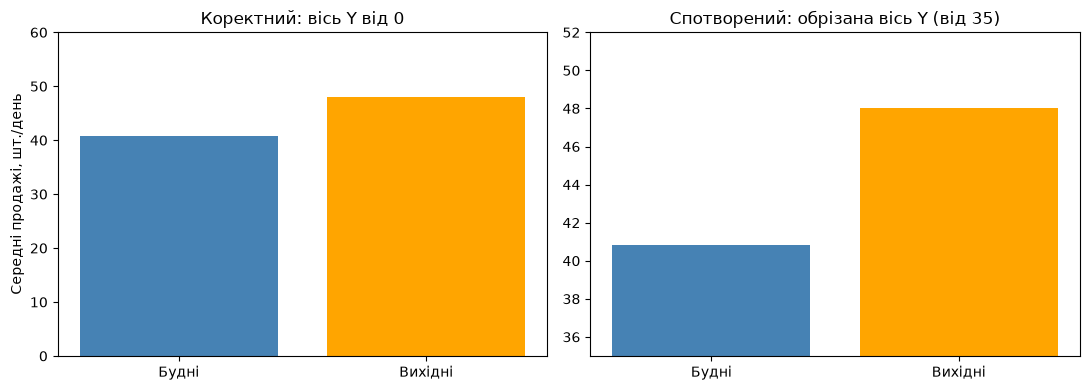

In [6]:
avg_sales = df.groupby("вихідний")["продажі"].mean()
categories = ["Будні", "Вихідні"]

fig, (ax_corr, ax_dist) = plt.subplots(1, 2, figsize=(11, 4))

ax_corr.bar(categories, avg_sales, color=["steelblue", "orange"])
ax_corr.set_ylim(0, 60)
ax_corr.set_ylabel("Середні продажі, шт./день")
ax_corr.set_title("Коректний: вісь Y від 0")

ax_dist.bar(categories, avg_sales, color=["steelblue", "orange"])
ax_dist.set_ylim(35, 52)  
ax_dist.set_title("Спотворений: обрізана вісь Y (від 35)")

plt.tight_layout()
plt.show()